## Experiment 2: Implement maximum likelihood estimation (MLE) for a given dataset and estimate the parameters of a selected probability distribution.


### Steps:
1.  **Generate Synthetic Data**: Create a dataset from a known distribution (e.g., normal distribution).
2.  **Define Likelihood Function**: Write a function that calculates the likelihood (or log-likelihood) of the observed data given the distribution parameters.
3.  **Optimize**: Use a numerical optimization method to find the parameters that maximize the likelihood function.

### 1. Generate Synthetic Data (Normal Distribution)

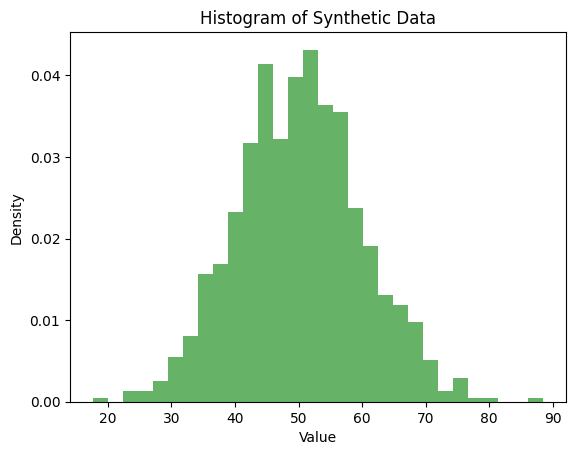

True Mean (mu): 50
True Standard Deviation (sigma): 10


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize

# True parameters for the normal distribution
true_mu = 50
true_sigma = 10

# Generate synthetic data
np.random.seed(42) # for reproducibility
data = np.random.normal(true_mu, true_sigma, 1000)

# Plot the histogram of the generated data
plt.hist(data, bins=30, density=True, alpha=0.6, color='g')
plt.title('Histogram of Synthetic Data')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

print(f"True Mean (mu): {true_mu}")
print(f"True Standard Deviation (sigma): {true_sigma}")

### 2. Define the Log-Likelihood Function for a Normal Distribution

The probability density function (PDF) for a normal distribution is:

$f(x | \mu, \sigma) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)$

The likelihood function for $n$ independent observations is the product of their PDFs:

$L(\mu, \sigma | \mathbf{x}) = \prod_{i=1}^{n} \frac{1}{\sigma \sqrt{2\pi}} \exp\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right)$

It's often easier to work with the log-likelihood function, which converts products to sums:

$\ln L(\mu, \sigma | \mathbf{x}) = \sum_{i=1}^{n} \ln\left(\frac{1}{\sigma \sqrt{2\pi}}\right) - \sum_{i=1}^{n} \frac{(x_i - \mu)^2}{2\sigma^2}$

We typically want to *maximize* the log-likelihood. However, most optimization routines are designed for *minimization*. So, we will define the negative log-likelihood function.


In [2]:
def negative_log_likelihood(params, data):
    mu, sigma = params

    # Ensure sigma is positive (standard deviation cannot be negative)
    if sigma <= 0:
        return np.inf

    # Calculate the log-likelihood using scipy.stats.norm.logpdf
    # The sum of log-PDFs is the log-likelihood for independent observations
    log_likelihood = np.sum(norm.logpdf(data, loc=mu, scale=sigma))

    # We want to minimize the negative log-likelihood
    return -log_likelihood

print("Negative Log-Likelihood function defined.")

Negative Log-Likelihood function defined.


### 3. Optimize to Estimate Parameters


In [3]:
# Initial guess for the parameters (mu, sigma)
# A common strategy is to use sample mean and standard deviation as initial guesses
initial_mu = np.mean(data)
initial_sigma = np.std(data)
initial_params = [initial_mu, initial_sigma]

print(f"Initial guess for mu: {initial_mu:.2f}")
print(f"Initial guess for sigma: {initial_sigma:.2f}")

# Define bounds for the parameters: sigma must be positive
bounds = [(None, None), (1e-6, None)] # mu can be anything, sigma must be > 0

# Perform the optimization
result = minimize(negative_log_likelihood, initial_params, args=(data,),
                  method='L-BFGS-B', bounds=bounds)

# Extract the estimated parameters
estimated_mu, estimated_sigma = result.x

print(f"\nOptimization successful: {result.success}")
print(f"Message: {result.message}")

print(f"\nEstimated Mean (mu): {estimated_mu:.2f}")
print(f"Estimated Standard Deviation (sigma): {estimated_sigma:.2f}")

print(f"\nTrue Mean (mu): {true_mu}")
print(f"True Standard Deviation (sigma): {true_sigma}")

Initial guess for mu: 50.19
Initial guess for sigma: 9.79

Optimization successful: True
Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL

Estimated Mean (mu): 50.19
Estimated Standard Deviation (sigma): 9.79

True Mean (mu): 50
True Standard Deviation (sigma): 10


### Visualization of Estimated Distribution vs. Data


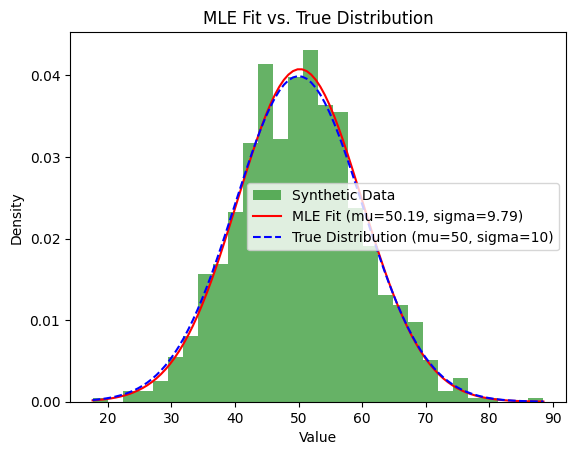

In [4]:
plt.hist(data, bins=30, density=True, alpha=0.6, color='g', label='Synthetic Data')

x = np.linspace(min(data), max(data), 100)
plt.plot(x, norm.pdf(x, loc=estimated_mu, scale=estimated_sigma), 'r-',
         label=f'MLE Fit (mu={estimated_mu:.2f}, sigma={estimated_sigma:.2f})')
plt.plot(x, norm.pdf(x, loc=true_mu, scale=true_sigma), 'b--',
         label=f'True Distribution (mu={true_mu}, sigma={true_sigma})')

plt.title('MLE Fit vs. True Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()